# <font color=#0099CC>**Full Pipeline — Inference + Backtest + Analysis**</font>

**Strategies** (all long-only, rebalanced every V_OUT trading days):
- **A (Equal Weight)** — Top-K positive exp. return assets, equal weight, hold to rebalance.
- **B (Take-Profit)** — Same as A, close positions exceeding expected return.
- **C (Proportional)** — Top-K positive, weight proportional to expected return.

**Benchmarks**:
- **BM1 (EW Fixed)** — Equal weight all 23 assets on day 1, never rebalance.
- **BM2 (EW Rebal)** — Equal weight all 23, reset every V_OUT days, drift in between.

**Rolling offsets**: runs the backtest starting at 0, 5, 10, 15, 20 trading day offsets
to reduce sensitivity to a single starting date.

---
## <font color=#0099CC>**1. ENVIRONMENT**</font>

In [44]:
import os, sys, json, shutil, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore', category=FutureWarning)

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()
if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
PORTFOLIO_DIR = os.path.join(BASE, '11_Portfolio')
for p in [SRC, PORTFOLIO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

cache = os.path.join(PORTFOLIO_DIR, '__pycache__')
if os.path.isdir(cache): shutil.rmtree(cache)

print(f'> Entorno: {ENV}\n> BASE: {BASE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
> Entorno: colab
> BASE: /content/drive/MyDrive/Taller4_DL_MIAX


---
## <font color=#0099CC>**2. PARAMETERS**</font>

In [45]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CHANGE THESE TO TEST A DIFFERENT MODEL                  ║
# ╚══════════════════════════════════════════════════════════╝
ARCH  = 'cnn'     # 'cnn' | 'conv1d' | 'mlp' | 'rnn' | 'mixto'
V_IN  = 10        # must match checkpoint

# ╔══════════════════════════════════════════════════════════╗
# ║  STRATEGY / BACKTEST PARAMETERS                          ║
# ╚══════════════════════════════════════════════════════════╝
V_OUT           = 90
TOP_K           = 5
CASH_RATE       = 0.0
DATA_START_YEAR = '2025-01-01'   # earliest possible start
DATA_END_BUFFER = 120            # extra trading days after last possible rebal
OFFSETS         = [0, 5, 10, 15, 20]  # rolling start offsets (trading days)

# ── Derived ──
MODELO  = f'inv_{ARCH}'
RUN_TAG = f'inv_{ARCH}_vin{V_IN}_vout{V_OUT}'
CKPT_NAME = f'{MODELO}_vin{V_IN}_vout{V_OUT}_best.weights.h5'
CKPT_PATH = os.path.join(BASE, '08_results', 'checkpoints', CKPT_NAME)
OUT_DIR   = os.path.join(PORTFOLIO_DIR, RUN_TAG)
os.makedirs(OUT_DIR, exist_ok=True)

# Clear old files before generating new ones
for f_old in os.listdir(OUT_DIR):
    fp = os.path.join(OUT_DIR, f_old)
    if os.path.isfile(fp): os.remove(fp)

from dataset_utils import (
    TICKERS, D_FRAC_INV, RANDOM_STATE_VAL,
    load_data, create_dataset, get_partitions_temporal,
)
TICKERS = list(TICKERS)
N_ASSETS = len(TICKERS)

print(f'-- Run: {RUN_TAG} --')
print(f'  ARCH={ARCH}  V_IN={V_IN}  V_OUT={V_OUT}  TOP_K={TOP_K}')
print(f'  Offsets: {OFFSETS}')
print(f'  Checkpoint: {CKPT_NAME}  exists={os.path.isfile(CKPT_PATH)}')
print(f'  Output: {OUT_DIR}')

-- Run: inv_cnn_vin10_vout90 --
  ARCH=cnn  V_IN=10  V_OUT=90  TOP_K=5
  Offsets: [0, 5, 10, 15, 20]
  Checkpoint: inv_cnn_vin10_vout90_best.weights.h5  exists=True
  Output: /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio/inv_cnn_vin10_vout90


---
## <font color=#0099CC>**3. SCALER & MODEL**</font>

In [46]:
# Reconstruct exact training scaler
data_fd, df_hist = load_data(d_frac=D_FRAC_INV, verbose=True)
X_all, Y_all = create_dataset(data_fd, V_IN, V_OUT, verbose=True)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test, scaler = get_partitions_temporal(
    X_all, Y_all, v_in=V_IN, v_out=V_OUT,
    scaler='standard', return_scaler=True,
    random_state=RANDOM_STATE_VAL, verbose=True,
)
print(f'\n> Scaler ready: mean={scaler.mean_[:3].round(4)}...')

> Descargando datos desde 1945-01-01 hasta hoy...


[*********************100%***********************]  23 of 23 completed


> Frac-diff aplicada — d=0.4, L=1458 pesos, 1457 filas iniciales descartadas (~8.99% del histórico).
> Shape resultante: (14747, 23)
> Dataset creado — X: (14648, 10, 23), Y: (14648, 23)
> Scaler: standard fitted on X_tr only — applied to train/val/test
> Split temporal con embargo  (v_in=10, v_out=90, embargo=100)
  Train   [     0,  11518)  ->   11518 muestras
  Val     [ 11618,  13083)  ->    1465 muestras  (gap previo: 100)
  Test    [ 13183,  14648)  ->    1465 muestras  (gap previo: 100)
  Descartadas por embargo: 200 muestras  (1.37% del total)

> Scaler ready: mean=[0.0629 0.079  0.0755]...


In [47]:
import tensorflow as tf
print(f'> TF {tf.__version__}, GPU: {tf.config.list_physical_devices("GPU")}')

import model_builder
importlib.reload(model_builder)
from model_builder import build_model

model = build_model(ARCH, V_IN, N_ASSETS)
model.load_weights(CKPT_PATH)
print(f'> Loaded: {CKPT_NAME} ({model.count_params():,} params)')

from metrics_utils import calc_mae_all
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
maes = calc_mae_all(model, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)
print(f'> MAE  tr={maes["train"]:.5f}  val={maes["val"]:.5f}  test={maes["test"]:.5f}')

> TF 2.20.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
> Loaded: inv_cnn_vin10_vout90_best.weights.h5 (39,703 params)
> MAE  tr=0.01865  val=0.02156  test=0.02600


---
## <font color=#0099CC>**4. DOWNLOAD PRICE DATA**</font>

In [48]:
import data_loader
importlib.reload(data_loader)
from data_loader import download_prices, get_trading_dates, compute_rebalancing_dates, prepare_log_prices
from frac_diff_utils import ffd_weights, ffd_invert_expected_return

# Frac-diff from training pipeline
fd_full = pd.DataFrame(data_fd, index=df_hist.index[-len(data_fd):], columns=TICKERS)

# Download prices with wide window (need data beyond 2025 for last rebalancing window)
dl_start = str(pd.Timestamp(DATA_START_YEAR) - pd.DateOffset(years=10))
dl_end   = str(pd.Timestamp('today') + pd.DateOffset(days=1))
prices_df = download_prices(TICKERS, start=dl_start, end=dl_end, verbose=True)
log_prices = prepare_log_prices(prices_df)

# All available trading dates from DATA_START_YEAR to latest data
all_trading = get_trading_dates(prices_df, DATA_START_YEAR, str(prices_df.index[-1].date()))
daily_returns = prices_df.pct_change().loc[all_trading]

# FFD weights
weights_ffd = ffd_weights(D_FRAC_INV, 1e-5)

print(f'\n> Available trading days: {len(all_trading)} ({all_trading[0].date()} -> {all_trading[-1].date()})')

> yfinance version : 0.2.66
> Downloading 23 tickers individually (2015-01-01 -> 2026-05-21) ...
  [ 1/23]   AEP  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 2/23]    BA  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 3/23]   CAT  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 4/23]   CNP  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 5/23]   CVX  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 6/23]   DIS  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 7/23]   DTE  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 8/23]    ED  2,862 days  [2015-01-02 -> 2026-05-20]
  [ 9/23]    GD  2,862 days  [2015-01-02 -> 2026-05-20]
  [10/23]    GE  2,862 days  [2015-01-02 -> 2026-05-20]
  [11/23]   HON  2,862 days  [2015-01-02 -> 2026-05-20]
  [12/23]   HPQ  2,862 days  [2015-01-02 -> 2026-05-20]
  [13/23]   IBM  2,862 days  [2015-01-02 -> 2026-05-20]
  [14/23]    IP  2,862 days  [2015-01-02 -> 2026-05-20]
  [15/23]   JNJ  2,862 days  [2015-01-02 -> 2026-05-20]
  [16/23]    KO  2,862 days  [2015-01-02 -> 2026-05-20]
  [17/2

---
## <font color=#0099CC>**5. CORE ENGINE**</font>

In [49]:
def run_inference_at_date(rebal_date):
    """Run model inference at a rebalancing date. Returns (pred_fd, exp_ret) arrays."""
    fd_up_to = fd_full.loc[:rebal_date]
    if len(fd_up_to) < V_IN:
        return None, None
    window = scaler.transform(fd_up_to.iloc[-V_IN:].values)
    pred = model.predict(window[np.newaxis, ...], verbose=0).squeeze()
    lp = log_prices.loc[:rebal_date].values
    exp_ret = ffd_invert_expected_return(pred, lp, weights_ffd, V_OUT)
    return pred, exp_ret


def select_top_k(exp_ret, tickers, top_k):
    """Returns list of (ticker, expected_return) for top-K positive assets."""
    pairs = sorted(zip(tickers, exp_ret), key=lambda x: x[1], reverse=True)
    selected = [(t, er) for t, er in pairs[:top_k] if er > 0]
    return selected


def run_single_backtest(offset, verbose=False):
    """
    Run full backtest with a given start offset.
    Returns dict with NAV series, per-window details, and summary metrics.
    """
    daily_rf = (1 + CASH_RATE) ** (1/252) - 1

    # Determine trading dates for this offset
    start_idx = offset
    bt_trading = all_trading[start_idx:]
    rebal_dates = compute_rebalancing_dates(bt_trading, V_OUT)

    # Ensure we have V_OUT days after the last rebalancing date
    last_rebal_idx = list(bt_trading).index(rebal_dates[-1])
    end_idx = min(last_rebal_idx + V_OUT, len(bt_trading) - 1)
    bt_trading = bt_trading[:end_idx + 1]

    # Alert if last window is short
    last_window_days = end_idx - last_rebal_idx
    alerts = []
    if last_window_days < V_OUT:
        alerts.append(f'Last window: {last_window_days}/{V_OUT} days (data ends {bt_trading[-1].date()})')

    if verbose:
        print(f'\n  Offset {offset}: {bt_trading[0].date()} -> {bt_trading[-1].date()} '
              f'({len(bt_trading)}d, {len(rebal_dates)} rebal dates)')

    # NAV trackers
    nav_a = [1.0]; nav_b = [1.0]; nav_c = [1.0]
    nav_bm1 = [1.0]; nav_bm2 = [1.0]

    # State
    hold_a = {};  cash_a = 1.0
    hold_b = {};  cash_b = 1.0; cum_ret_b = {}; closed_b = set()
    hold_c = {};  cash_c = 1.0
    bm2_w = pd.Series(1.0/N_ASSETS, index=TICKERS)
    cur_window = -1
    window_log = []

    for day_idx, date in enumerate(bt_trading):
        # Determine rebalancing window
        w_idx = 0
        for i in range(len(rebal_dates)-1, -1, -1):
            if date >= rebal_dates[i]: w_idx = i; break

        # ── Rebalancing ──
        if w_idx != cur_window:
            cur_window = w_idx
            rd = rebal_dates[w_idx]
            _, exp_ret = run_inference_at_date(rd)
            if exp_ret is None:
                selected = []
            else:
                selected = select_top_k(exp_ret, TICKERS, TOP_K)

            # Strategy A: equal weight
            w_eq = 1.0 / TOP_K if selected else 0
            hold_a = {t: w_eq for t, _ in selected}
            cash_a = 1.0 - w_eq * len(selected)

            # Strategy B: equal weight + take-profit
            hold_b = {t: (w_eq, er) for t, er in selected}
            cash_b = cash_a
            cum_ret_b = {t: 0.0 for t, _ in selected}
            closed_b = set()

            # Strategy C: proportional weight
            if selected:
                total_er = sum(er for _, er in selected)
                if total_er > 0:
                    hold_c = {t: er / total_er for t, er in selected}
                    cash_c = 0.0
                else:
                    hold_c = {}; cash_c = 1.0
            else:
                hold_c = {}; cash_c = 1.0

            # BM2: reset to equal weight
            bm2_w = pd.Series(1.0/N_ASSETS, index=TICKERS)

            # Compute expected portfolio returns for each strategy
            exp_port_a = sum(w_eq * er for _, er in selected) if selected else 0
            exp_port_c = sum(hold_c.get(t,0) * er for t, er in selected) if selected else 0

            window_log.append({
                'window': w_idx, 'rebal_date': rd.strftime('%Y-%m-%d'),
                'selected': [t for t, _ in selected],
                'exp_returns': [er for _, er in selected],
                'weights_c': {t: hold_c.get(t, 0) for t, _ in selected},
                'n_selected': len(selected),
                'exp_port_ret_a': exp_port_a,
                'exp_port_ret_c': exp_port_c,
            })

        if day_idx == 0:
            continue

        dr = daily_returns.loc[date]

        # Strategy A
        ret_a = sum(hold_a.get(t,0) * dr[t] for t in TICKERS) + cash_a * daily_rf
        nav_a.append(nav_a[-1] * (1 + ret_a))

        # Strategy B
        ret_b = 0.0
        for t in list(hold_b):
            if t in closed_b: continue
            w, thr = hold_b[t]
            cum_ret_b[t] = (1 + cum_ret_b[t]) * (1 + dr[t]) - 1
            ret_b += w * dr[t]
            if cum_ret_b[t] >= thr:
                closed_b.add(t); cash_b += w
        ret_b += cash_b * daily_rf
        nav_b.append(nav_b[-1] * (1 + ret_b))

        # Strategy C
        ret_c = sum(hold_c.get(t,0) * dr[t] for t in TICKERS) + cash_c * daily_rf
        nav_c.append(nav_c[-1] * (1 + ret_c))

        # BM1: fixed weights (just track normalised prices)
        # BM2: drifting weights
        ret_bm2 = (bm2_w * dr).sum()
        nav_bm2.append(nav_bm2[-1] * (1 + ret_bm2))
        bm2_w = bm2_w * (1 + dr)
        bm2_w = bm2_w / bm2_w.sum()

    # BM1: computed from normalised prices (exact, no loop needed)
    ew = 1.0 / N_ASSETS
    norm_p = prices_df.loc[bt_trading] / prices_df.loc[bt_trading[0]]
    nav_bm1_series = (norm_p * ew).sum(axis=1)

    nav_dates = bt_trading[:len(nav_a)]

    # Compute actual portfolio returns per window
    for wl in window_log:
        rd = pd.Timestamp(wl['rebal_date'])
        rd_idx = list(bt_trading).index(rd)
        end_idx = min(rd_idx + V_OUT, len(bt_trading) - 1)
        end_date = bt_trading[end_idx]
        wl['end_date'] = end_date.strftime('%Y-%m-%d')
        wl['actual_days'] = end_idx - rd_idx

        actual_rets = {}
        for t in wl['selected']:
            p0 = prices_df.loc[rd, t]
            p1 = prices_df.loc[end_date, t]
            actual_rets[t] = (p1 / p0) - 1
        wl['actual_returns'] = actual_rets

        # Actual portfolio return (equal weight)
        if wl['selected']:
            w_eq = 1.0 / TOP_K
            wl['actual_port_ret_a'] = sum(w_eq * actual_rets[t] for t in wl['selected'])
            wl['actual_port_ret_c'] = sum(wl['weights_c'][t] * actual_rets[t] for t in wl['selected'])
        else:
            wl['actual_port_ret_a'] = 0
            wl['actual_port_ret_c'] = 0

    # Spearman per window
    from scipy.stats import spearmanr
    for wl in window_log:
        rd = pd.Timestamp(wl['rebal_date'])
        end_date = pd.Timestamp(wl['end_date'])
        _, exp_full = run_inference_at_date(rd)
        if exp_full is not None:
            actual_full = [(prices_df.loc[end_date, t] / prices_df.loc[rd, t]) - 1 for t in TICKERS]
            corr, pval = spearmanr(exp_full, actual_full)
            wl['spearman_rho'] = corr
            wl['spearman_p'] = pval
            n_dir = sum(1 for e, a in zip(exp_full, actual_full) if np.sign(e) == np.sign(a))
            wl['direction_pct'] = n_dir / N_ASSETS
        else:
            wl['spearman_rho'] = None
            wl['spearman_p'] = None
            wl['direction_pct'] = None

    # Print alerts
    if verbose:
        for a in alerts:
            print(f'    \u26a0 {a}')

    result = {
        'offset': offset,
        'start': bt_trading[0].strftime('%Y-%m-%d'),
        'end': bt_trading[-1].strftime('%Y-%m-%d'),
        'n_days': len(bt_trading),
        'nav': {
            'Strategy A (Equal Wt)': pd.Series(nav_a, index=nav_dates),
            'Strategy B (Take-Profit)': pd.Series(nav_b, index=nav_dates),
            'Strategy C (Proportional)': pd.Series(nav_c, index=nav_dates),
            'BM1: EW Fixed': nav_bm1_series.loc[nav_dates],
            'BM2: EW Rebal': pd.Series(nav_bm2, index=nav_dates),
        },
        'window_log': window_log,
        'alerts': alerts,
        'final_ret': {
            'A': nav_a[-1] - 1,
            'B': nav_b[-1] - 1,
            'C': nav_c[-1] - 1,
            'BM1': float(nav_bm1_series.iloc[-1]) - 1,
            'BM2': nav_bm2[-1] - 1,
        },
    }
    return result

print('Engine ready.')

Engine ready.


---
## <font color=#0099CC>**6. RUN ALL OFFSETS**</font>

In [50]:
results = []
for off in OFFSETS:
    r = run_single_backtest(off, verbose=True)
    results.append(r)
    print(f'    Final returns: A={r["final_ret"]["A"]:+.2%}  '
          f'B={r["final_ret"]["B"]:+.2%}  '
          f'C={r["final_ret"]["C"]:+.2%}  '
          f'BM1={r["final_ret"]["BM1"]:+.2%}  '
          f'BM2={r["final_ret"]["BM2"]:+.2%}')

print(f'\n> {len(results)} offset runs completed.')


  Offset 0: 2025-01-02 -> 2026-05-20 (346d, 4 rebal dates)
    ⚠ Last window: 75/90 days (data ends 2026-05-20)
    Final returns: A=+13.75%  B=+16.65%  C=+67.24%  BM1=+27.91%  BM2=+26.19%

  Offset 5: 2025-01-10 -> 2026-05-20 (341d, 4 rebal dates)
    ⚠ Last window: 70/90 days (data ends 2026-05-20)
    Final returns: A=+16.20%  B=+12.90%  C=+29.45%  BM1=+28.87%  BM2=+27.50%

  Offset 10: 2025-01-17 -> 2026-05-20 (336d, 4 rebal dates)
    ⚠ Last window: 65/90 days (data ends 2026-05-20)
    Final returns: A=+21.78%  B=+15.24%  C=+16.58%  BM1=+24.47%  BM2=+23.51%

  Offset 15: 2025-01-27 -> 2026-05-20 (331d, 4 rebal dates)
    ⚠ Last window: 60/90 days (data ends 2026-05-20)
    Final returns: A=+22.77%  B=+17.29%  C=+44.30%  BM1=+21.69%  BM2=+20.95%

  Offset 20: 2025-02-03 -> 2026-05-20 (326d, 4 rebal dates)
    ⚠ Last window: 55/90 days (data ends 2026-05-20)
    Final returns: A=+10.06%  B=+5.51%  C=+22.05%  BM1=+22.83%  BM2=+21.16%

> 5 offset runs completed.


---
## <font color=#0099CC>**7. RESULTS TABLE — Per Offset + Average**</font>

In [51]:
# ── Per-offset total returns ──
rows = []
for r in results:
    row = {'Offset': r['offset'], 'Period': f'{r["start"]} -> {r["end"]}',
           'Days': r['n_days']}
    for k, v in r['final_ret'].items():
        row[k] = v
    rows.append(row)

# Average row
avg = {'Offset': 'AVG', 'Period': '', 'Days': ''}
for k in ['A', 'B', 'C', 'BM1', 'BM2']:
    vals = [r['final_ret'][k] for r in results]
    avg[k] = np.mean(vals)
rows.append(avg)

# Std row
std = {'Offset': 'STD', 'Period': '', 'Days': ''}
for k in ['A', 'B', 'C', 'BM1', 'BM2']:
    vals = [r['final_ret'][k] for r in results]
    std[k] = np.std(vals)
rows.append(std)

summary_df = pd.DataFrame(rows)

# Format for display
disp = summary_df.copy()
for c in ['A', 'B', 'C', 'BM1', 'BM2']:
    disp[c] = disp[c].apply(lambda x: f'{x:+.2%}' if isinstance(x, (int, float)) else x)

print('-- Total Returns by Offset --')
print(disp.to_string(index=False))

-- Total Returns by Offset --
Offset                   Period Days       A       B       C     BM1     BM2
     0 2025-01-02 -> 2026-05-20  346 +13.75% +16.65% +67.24% +27.91% +26.19%
     5 2025-01-10 -> 2026-05-20  341 +16.20% +12.90% +29.45% +28.87% +27.50%
    10 2025-01-17 -> 2026-05-20  336 +21.78% +15.24% +16.58% +24.47% +23.51%
    15 2025-01-27 -> 2026-05-20  331 +22.77% +17.29% +44.30% +21.69% +20.95%
    20 2025-02-03 -> 2026-05-20  326 +10.06%  +5.51% +22.05% +22.83% +21.16%
   AVG                               +16.91% +13.52% +35.93% +25.15% +23.86%
   STD                                +4.80%  +4.28% +18.22%  +2.80%  +2.63%


In [52]:
# ── Per-window expected vs actual returns (offset=0) ──
print('\n-- Per-Window Expected vs Actual (offset=0) --')
print(f'{"Window":>6s}  {"Period":>30s}  {"Strat":>5s}  {"Exp.Port":>10s}  {"Act.Port":>10s}  {"Diff":>10s}')
print('-' * 78)
for wl in results[0]['window_log']:
    period = f'{wl["rebal_date"]} -> {wl["end_date"]}'
    # Strategy A
    print(f'{wl["window"]:>6d}  {period:>30s}  {"A":>5s}  '
          f'{wl["exp_port_ret_a"]:>+10.4%}  {wl["actual_port_ret_a"]:>+10.4%}  '
          f'{wl["exp_port_ret_a"] - wl["actual_port_ret_a"]:>+10.4%}')
    # Strategy C
    print(f'{"":>6s}  {"":>30s}  {"C":>5s}  '
          f'{wl["exp_port_ret_c"]:>+10.4%}  {wl["actual_port_ret_c"]:>+10.4%}  '
          f'{wl["exp_port_ret_c"] - wl["actual_port_ret_c"]:>+10.4%}')

# Asset-level detail
print('\n-- Asset-Level Detail (offset=0) --')
for wl in results[0]['window_log']:
    print(f'\n  Window {wl["window"]}: {wl["rebal_date"]} -> {wl["end_date"]} ({wl["actual_days"]}d)')
    print(f'  Spearman rho={wl["spearman_rho"]:.3f}  Dir%={wl["direction_pct"]:.1%}')
    print(f'  {"Asset":>6s}  {"Wt(A)":>6s}  {"Wt(C)":>6s}  {"Exp":>9s}  {"Actual":>9s}  {"Dir?":>4s}')
    print(f'  {"-"*50}')
    w_eq = 1.0/TOP_K if wl['selected'] else 0
    for t, er in zip(wl['selected'], wl['exp_returns']):
        ar = wl['actual_returns'][t]
        wc = wl['weights_c'][t]
        hit = 'Y' if np.sign(er) == np.sign(ar) else 'N'
        print(f'  {t:>6s}  {w_eq:>6.1%}  {wc:>6.1%}  {er:>+9.4%}  {ar:>+9.4%}  {hit:>4s}')


-- Per-Window Expected vs Actual (offset=0) --
Window                          Period  Strat    Exp.Port    Act.Port        Diff
------------------------------------------------------------------------------
     0        2025-01-02 -> 2025-05-14      A    +6.7406%    +1.3149%    +5.4257%
                                            C    +9.9626%    +5.8721%    +4.0905%
     1        2025-05-14 -> 2025-09-23      A    +7.5234%    +8.4724%    -0.9490%
                                            C   +15.2508%   +13.0894%    +2.1614%
     2        2025-09-23 -> 2026-02-02      A    +0.3323%    +8.5990%    -8.2667%
                                            C    +1.6617%   +42.9952%   -41.3335%
     3        2026-02-02 -> 2026-05-20      A   +13.0260%    -2.1575%   +15.1835%
                                            C   +21.9155%    +2.5793%   +19.3363%

-- Asset-Level Detail (offset=0) --

  Window 0: 2025-01-02 -> 2025-05-14 (90d)
  Spearman rho=0.147  Dir%=39.1%
   Asset   Wt(A)   Wt

---
## <font color=#0099CC>**8. VISUALISATION**</font>

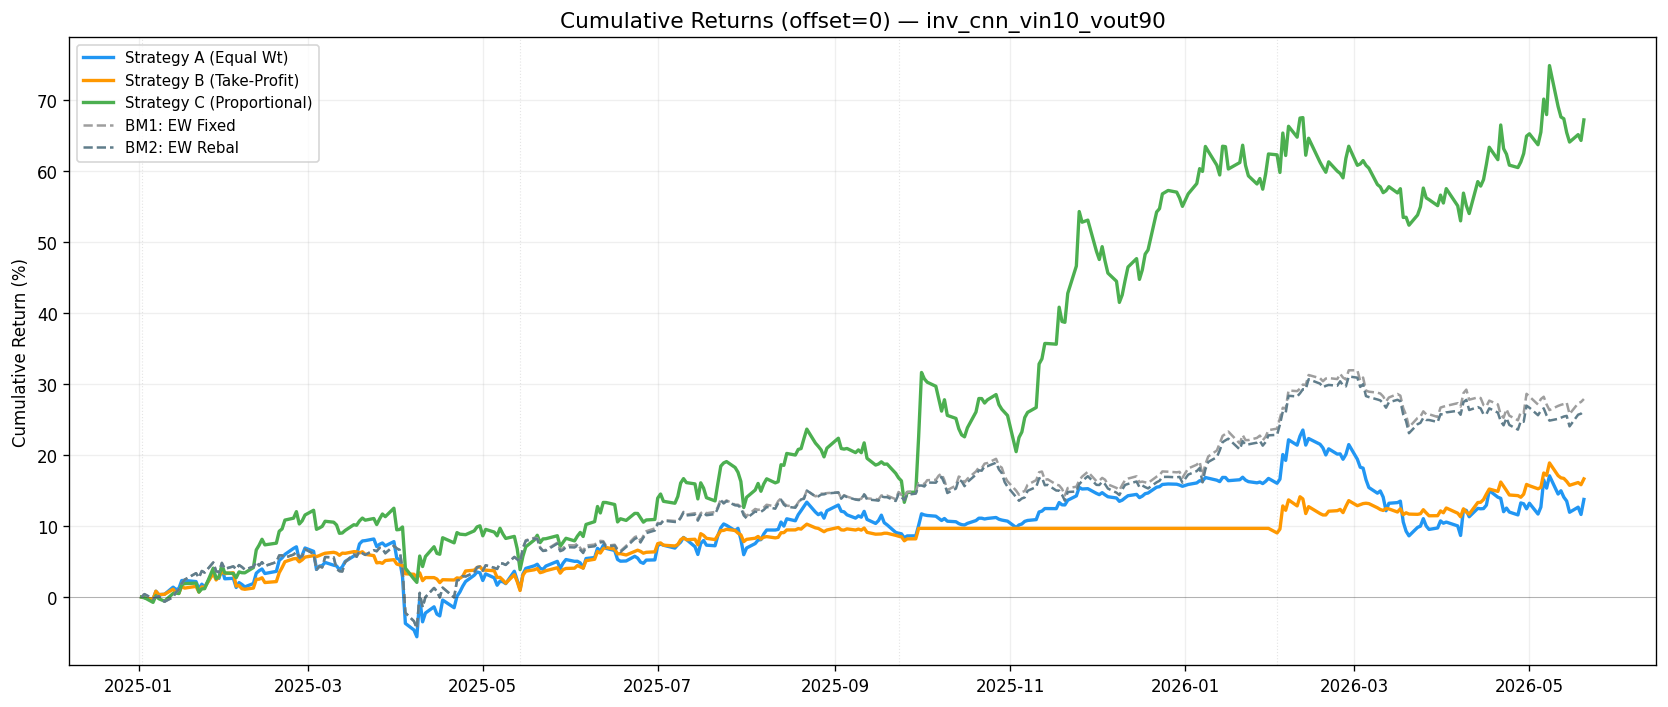

In [53]:
COLORS = {
    'Strategy A (Equal Wt)':     '#2196F3',
    'Strategy B (Take-Profit)':  '#FF9800',
    'Strategy C (Proportional)': '#4CAF50',
    'BM1: EW Fixed':             '#9E9E9E',
    'BM2: EW Rebal':             '#607D8B',
}
LW = {'Strategy A (Equal Wt)': 2, 'Strategy B (Take-Profit)': 2,
      'Strategy C (Proportional)': 2, 'BM1: EW Fixed': 1.5, 'BM2: EW Rebal': 1.5}
LS = {'Strategy A (Equal Wt)': '-', 'Strategy B (Take-Profit)': '-',
      'Strategy C (Proportional)': '-', 'BM1: EW Fixed': '--', 'BM2: EW Rebal': '--'}

# ── Chart 1: Cumulative returns for offset=0 ──
fig, ax = plt.subplots(figsize=(14, 6))
for name, nav in results[0]['nav'].items():
    ax.plot(nav.index, (nav - 1) * 100,
            label=name, color=COLORS[name], lw=LW[name], ls=LS[name])
rebal_dates_0 = compute_rebalancing_dates(
    all_trading[OFFSETS[0]:], V_OUT)
for rd in rebal_dates_0:
    ax.axvline(rd, color='gray', alpha=0.2, ls=':', lw=0.7)
ax.axhline(0, color='black', lw=0.5, alpha=0.3)
ax.set_title(f'Cumulative Returns (offset=0) — {RUN_TAG}', fontsize=13)
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cumulative_returns_offset0.png'), dpi=150, bbox_inches='tight')
plt.show()

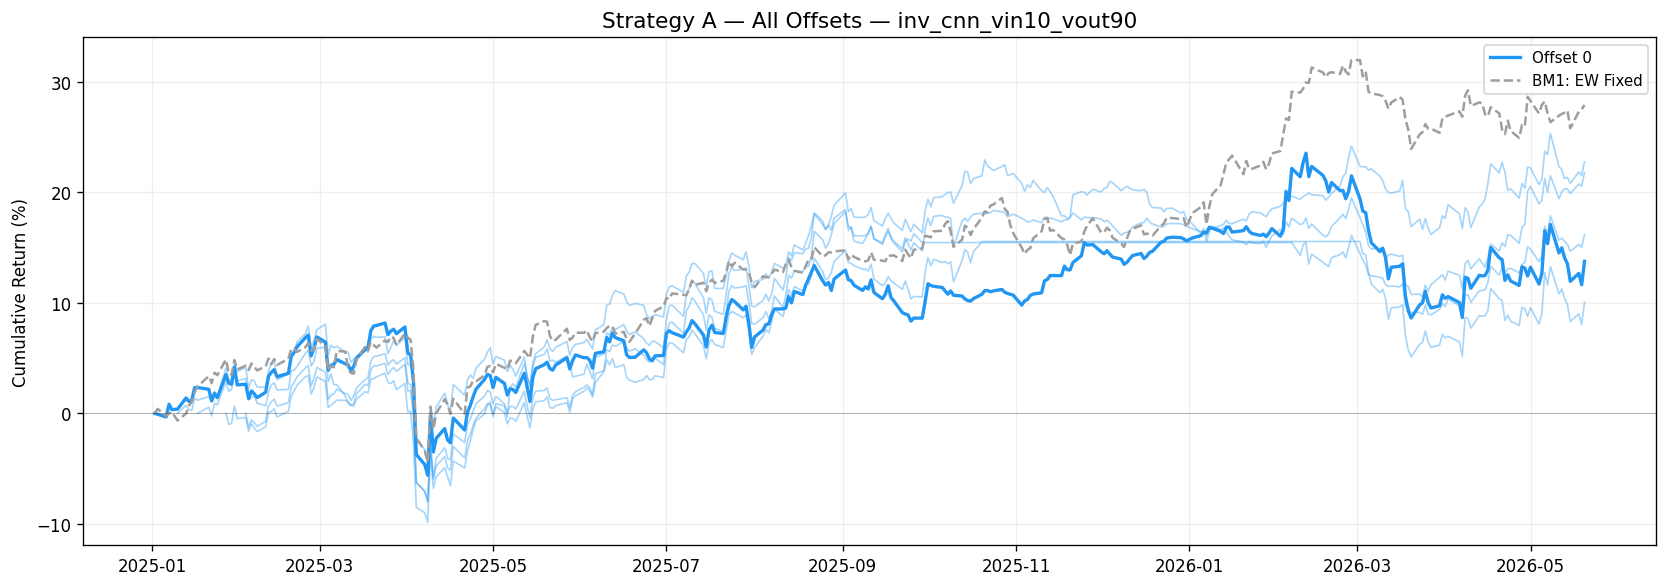

In [54]:
# ── Chart 2: All offsets overlaid for Strategy A ──
fig, ax = plt.subplots(figsize=(14, 5))
for r in results:
    nav = r['nav']['Strategy A (Equal Wt)']
    alpha = 1.0 if r['offset'] == 0 else 0.4
    lw = 2.0 if r['offset'] == 0 else 1.0
    ax.plot(nav.index, (nav-1)*100, color='#2196F3', alpha=alpha, lw=lw,
            label=f'Offset {r["offset"]}' if r['offset'] == 0 else '')
# BM1 reference
nav_bm = results[0]['nav']['BM1: EW Fixed']
ax.plot(nav_bm.index, (nav_bm-1)*100, color='#9E9E9E', ls='--', lw=1.5, label='BM1: EW Fixed')
ax.axhline(0, color='black', lw=0.5, alpha=0.3)
ax.set_title(f'Strategy A — All Offsets — {RUN_TAG}', fontsize=13)
ax.set_ylabel('Cumulative Return (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'strat_a_all_offsets.png'), dpi=150, bbox_inches='tight')
plt.show()

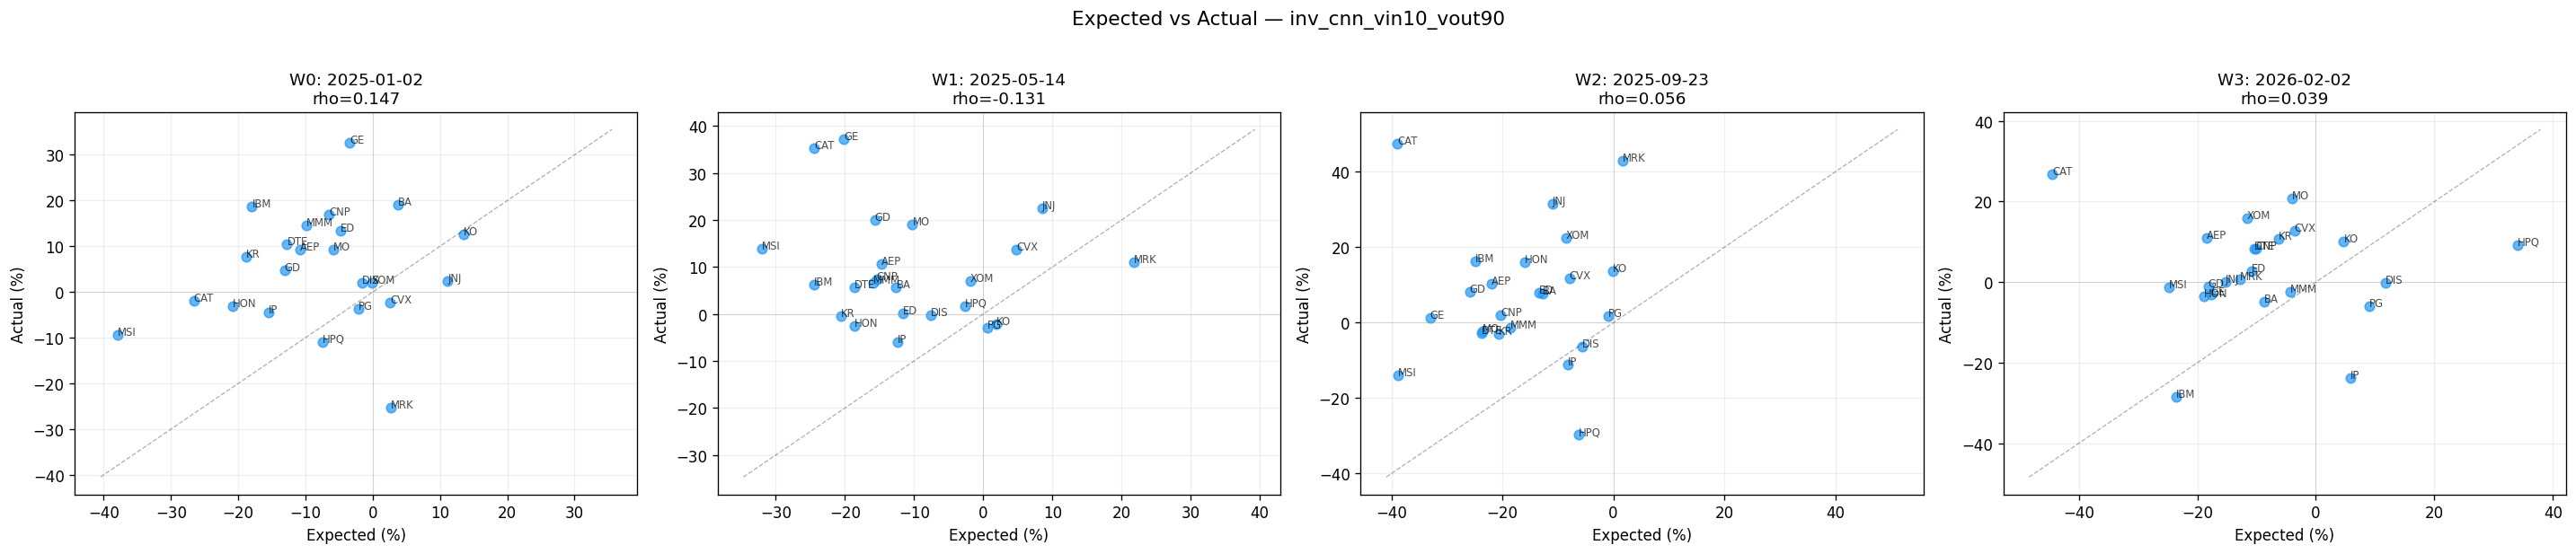

In [55]:
# ── Chart 3: Expected vs Actual scatter (offset=0) ──
wlogs = results[0]['window_log']
n_w = len(wlogs)
fig, axes = plt.subplots(1, n_w, figsize=(6*n_w, 5))
if n_w == 1: axes = [axes]

for i, wl in enumerate(wlogs):
    rd = pd.Timestamp(wl['rebal_date'])
    ed = pd.Timestamp(wl['end_date'])
    _, exp_full = run_inference_at_date(rd)
    actual_full = np.array([(prices_df.loc[ed, t]/prices_df.loc[rd, t])-1 for t in TICKERS])

    ax = axes[i]
    ax.scatter(exp_full*100, actual_full*100, alpha=0.7, s=40, color='#2196F3')
    for j, t in enumerate(TICKERS):
        ax.annotate(t, (exp_full[j]*100, actual_full[j]*100), fontsize=7, alpha=0.7)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, lw=0.8)
    ax.axhline(0, color='gray', alpha=0.3, lw=0.5)
    ax.axvline(0, color='gray', alpha=0.3, lw=0.5)
    rho = wl['spearman_rho']
    ax.set_title(f'W{i}: {rd.date()}\nrho={rho:.3f}', fontsize=11)
    ax.set_xlabel('Expected (%)')
    ax.set_ylabel('Actual (%)')
    ax.grid(True, alpha=0.2)

plt.suptitle(f'Expected vs Actual — {RUN_TAG}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scatter_exp_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()

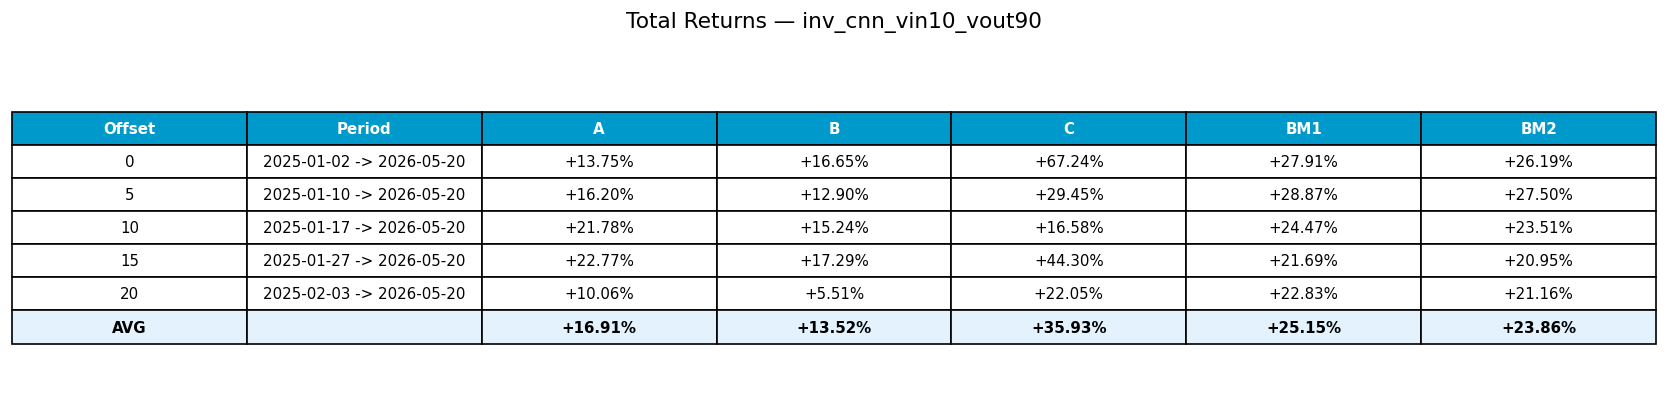

In [56]:
# ── Summary table as figure ──
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

col_labels = ['Offset', 'Period', 'A', 'B', 'C', 'BM1', 'BM2']
table_data = []
for r in results:
    table_data.append([
        str(r['offset']),
        f'{r["start"][:10]} -> {r["end"][:10]}',
        f'{r["final_ret"]["A"]:+.2%}',
        f'{r["final_ret"]["B"]:+.2%}',
        f'{r["final_ret"]["C"]:+.2%}',
        f'{r["final_ret"]["BM1"]:+.2%}',
        f'{r["final_ret"]["BM2"]:+.2%}',
    ])
# Average
table_data.append([
    'AVG', '',
    f'{np.mean([r["final_ret"]["A"] for r in results]):+.2%}',
    f'{np.mean([r["final_ret"]["B"] for r in results]):+.2%}',
    f'{np.mean([r["final_ret"]["C"] for r in results]):+.2%}',
    f'{np.mean([r["final_ret"]["BM1"] for r in results]):+.2%}',
    f'{np.mean([r["final_ret"]["BM2"] for r in results]):+.2%}',
])

table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.6)
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#0099CC')
    table[0, j].set_text_props(color='white', fontweight='bold')
# Highlight AVG row
avg_row = len(table_data)
for j in range(len(col_labels)):
    table[avg_row, j].set_facecolor('#E3F2FD')
    table[avg_row, j].set_text_props(fontweight='bold')

ax.set_title(f'Total Returns — {RUN_TAG}', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'summary_table.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## <font color=#0099CC>**9. SAVE ALL RESULTS**</font>

In [57]:


# Summary table
summary_df.to_csv(os.path.join(OUT_DIR, 'summary_returns.csv'), index=False)

# NAV series (offset=0)
pd.DataFrame(results[0]['nav']).to_csv(os.path.join(OUT_DIR, 'nav_series_offset0.csv'))

# Per-window detail (offset=0)
detail_rows = []
for wl in results[0]['window_log']:
    for t, er in zip(wl['selected'], wl['exp_returns']):
        ar = wl['actual_returns'][t]
        wc = wl['weights_c'][t]
        detail_rows.append({
            'window': wl['window'], 'rebal_date': wl['rebal_date'],
            'end_date': wl['end_date'], 'ticker': t,
            'weight_eq': 1.0/TOP_K, 'weight_prop': wc,
            'exp_return': er, 'actual_return': ar,
            'direction_correct': np.sign(er) == np.sign(ar),
        })
pd.DataFrame(detail_rows).to_csv(os.path.join(OUT_DIR, 'window_detail.csv'), index=False)

# Model metadata
meta = {
    'run_tag': RUN_TAG, 'arch': ARCH, 'v_in': V_IN, 'v_out': V_OUT,
    'd_frac': D_FRAC_INV, 'top_k': TOP_K, 'cash_rate': CASH_RATE,
    'n_assets': N_ASSETS, 'tickers': TICKERS,
    'offsets': OFFSETS,
    'mae_train': maes['train'], 'mae_val': maes['val'], 'mae_test': maes['test'],
    'avg_returns': {
        k: float(np.mean([r['final_ret'][k] for r in results]))
        for k in ['A', 'B', 'C', 'BM1', 'BM2']
    },
    'per_offset': [
        {'offset': r['offset'], 'start': r['start'], 'end': r['end'],
         'returns': r['final_ret']}
        for r in results
    ],
}
with open(os.path.join(OUT_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2, default=str)

print(f'All results saved to: {OUT_DIR}/')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')

All results saved to: /content/drive/MyDrive/Taller4_DL_MIAX/11_Portfolio/inv_cnn_vin10_vout90/
  cumulative_returns_offset0.png
  model_meta.json
  nav_series_offset0.csv
  scatter_exp_vs_actual.png
  strat_a_all_offsets.png
  summary_returns.csv
  summary_table.png
  window_detail.csv
